# Trait Correlation Analysis

This notebook walks through the complete analysis used to derive the **k=8 data-driven trait groups** for MTL/MMoE training.

**Pipeline summary:**
1. Load SPLOT center-pixel trait values from `chips_luca/patch7_stride3/train.zarr`
2. Compute per-trait statistics (sparsity, CV, etc.)
3. Compute the 37×37 pairwise Pearson correlation matrix
4. Visualize the raw correlation heatmap
5. Find the top most/least correlated trait pairs
6. Hierarchical clustering (Ward linkage, distance = 1 − |r|)
7. Compare k=4..10 using silhouette score and within-group correlation
8. Visualize sorted heatmaps for k=6, 7, 8
9. Final k=8 groups: biological interpretation
10. Save outputs: `analysis/trait_corr.npy`, `analysis/trait_groupings.yaml`

> **Note:** Steps 1–3 require access to the train.zarr file.  
> If you already have `analysis/trait_corr.npy`, run **Cell 7** to skip the data loading and go straight to visualisation.


## 0. Imports and configuration

In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import yaml
from scipy.cluster.hierarchy import dendrogram, fcluster, linkage
from scipy.spatial.distance import squareform
from scipy.stats import pearsonr
from sklearn.metrics import silhouette_score

# ── Paths ────────────────────────────────────────────────────────────────────
NOTEBOOK_DIR  = Path().resolve()          # PTEV2/notebooks/
REPO_ROOT     = NOTEBOOK_DIR.parent       # PTEV2/

ZARR_PATH     = Path("/scratch3/plant-traits-v2/data/22km/chips_luca/patch7_stride3/train.zarr")
ANALYSIS_DIR  = REPO_ROOT / "analysis"
VIZ_DIR       = REPO_ROOT / "viz" / "analysis"
ANALYSIS_DIR.mkdir(parents=True, exist_ok=True)
VIZ_DIR.mkdir(parents=True, exist_ok=True)

# ── Trait names (same order as chips_dataset.py) ─────────────────────────────
TRAIT_NAMES: list[str] = [
    "X1080", "X13",   "X138",  "X14",  "X144", "X145", "X146",
    "X15",   "X163",  "X169",  "X21",  "X223", "X224", "X237",
    "X26",   "X27",   "X281",  "X282", "X289", "X297", "X3106",
    "X3107", "X3112", "X3113", "X3114","X3117","X3120","X351",
    "X4",    "X46",   "X47",   "X50",  "X55",  "X6",   "X614",
    "X78",   "X95",
]
N_TRAITS = len(TRAIT_NAMES)   # 37
print(f"N_TRAITS = {N_TRAITS}")
print(f"REPO_ROOT = {REPO_ROOT}")
print(f"ZARR_PATH exists: {ZARR_PATH.exists()}")


/tmp/ipykernel_1174658/335575545.py:11: UserWarning: A NumPy version >=1.23.5 and <2.3.0 is required for this version of SciPy (detected version 2.4.2)
  from scipy.cluster.hierarchy import dendrogram, fcluster, linkage


N_TRAITS = 37
REPO_ROOT = /scratch3/plant-traits-v2/dsaini/plant-traits-earth-v2/PTEV2
ZARR_PATH exists: True


## 1. Load SPLOT center-pixel values from train.zarr

Each chip has a `splot` array shaped **(N, 222, P, P)** where 222 = 37 traits × 6 channels
(ch0=mean, ch1=n_obs, ch2=std, ch3=q25, ch4=q75, ...).
We extract only **channel 0** (mean) at the **center pixel** and use `isfinite()` to mask chips with no SPLOT observation.


In [2]:
import zarr

def load_splot_center_values(zarr_path: Path) -> np.ndarray:
    """Load SPLOT center-pixel mean values from chips_luca train.zarr.

    The chips_luca format stores 6 channels per trait in targets/splot:
        ch0=mean, ch1=n_obs, ch2=std, ch3=q25, ch4=q75, ...
    Channel 0 of each 6-group is the mean trait value; NaN = no observation.

    Returns (M, 37) float32 — rows with >=1 SPLOT observation, NaN where missing.
    """
    z = zarr.open(str(zarr_path), mode="r")
    patch_size = int(z.attrs.get("patch_size", 7))
    ci = patch_size // 2   # center pixel index (3 for patch7)

    # Load center-pixel means: (N, 37) — channel 0 of each 6-group
    splot_center = z["targets/splot"][:, :, ci, ci]    # (N, 222)
    values = splot_center[:, 0::6].astype(np.float32)  # (N, 37)

    has_any = np.any(np.isfinite(values), axis=1)
    print(f"  Total chips:       {values.shape[0]:,}")
    print(f"  Chips with SPLOT:  {has_any.sum():,}  ({100*has_any.mean():.1f}%)")
    return values[has_any]   # (M, 37)


print("Loading SPLOT center-pixel values ...")
values = load_splot_center_values(ZARR_PATH)
print(f"  Value matrix shape: {values.shape}")
print(f"  NaN fraction: {np.isnan(values).mean():.3f}")


Loading SPLOT center-pixel values ...
  Total chips:       46,375
  Chips with SPLOT:  2,570  (5.5%)
  Value matrix shape: (2570, 37)
  NaN fraction: 0.166


### 1b. Shortcut — load pre-computed correlation matrix (skip data loading)
If `analysis/trait_corr.npy` already exists you can run this cell and jump straight to visualisation.

In [ ]:
# ── Run this cell ONLY if you want to skip the zarr loading above ─────────
npy_path = ANALYSIS_DIR / "trait_corr.npy"
if npy_path.exists():
    corr = np.load(npy_path)
    print(f"Loaded pre-computed correlation matrix from {npy_path}  shape={corr.shape}")
    values = None   # mark as unavailable for per-trait stats
else:
    print(f"{npy_path} not found — run the cell above first.")

## 2. Per-trait statistics

For each of the 37 traits we compute: number of SPLOT observations, sparsity, mean, std, and coefficient of variation (CV = std / |mean|).

In [3]:
assert values is not None, "Run the zarr loading cell first."

M = values.shape[0]
n_obs    = np.sum(np.isfinite(values), axis=0)
sparsity = 1.0 - n_obs / M
mean_v   = np.nanmean(values, axis=0)
std_v    = np.nanstd(values,  axis=0)
cv       = np.where(np.abs(mean_v) > 1e-12, std_v / np.abs(mean_v), np.nan)

print(f"{'Trait':<10} {'n_obs':>8} {'sparsity':>10} {'mean':>10} {'std':>10} {'CV':>10}")
print("-" * 62)
for t in range(N_TRAITS):
    cv_s = f"{cv[t]:.3f}" if np.isfinite(cv[t]) else "  N/A"
    print(f"{TRAIT_NAMES[t]:<10} {n_obs[t]:>8,} {sparsity[t]:>10.3f} "
          f"{mean_v[t]:>10.4f} {std_v[t]:>10.4f} {cv_s:>10}")

Trait         n_obs   sparsity       mean        std         CV
--------------------------------------------------------------
X1080         2,107      0.180     0.0194     0.7940     40.901
X13           2,095      0.185     0.0572     0.7720     13.485
X138          2,103      0.182     0.3578     0.6914      1.932
X14           2,169      0.156    -0.0862     0.6292      7.300
X144          2,134      0.170    -0.2988     0.5251      1.757
X145          2,154      0.162    -0.5409     0.6502      1.202
X146          2,163      0.158     0.0422     0.6757     15.996
X15           2,122      0.174     0.2854     0.5741      2.012
X163          2,191      0.147    -0.4756     0.5223      1.098
X169          2,052      0.202     0.7703     0.7113      0.923
X21           2,093      0.186    -0.2148     0.6927      3.225
X223          2,092      0.186     0.1766     0.5484      3.106
X224          2,070      0.195     0.2217     0.7258      3.273
X237          2,187      0.149    -0.0596

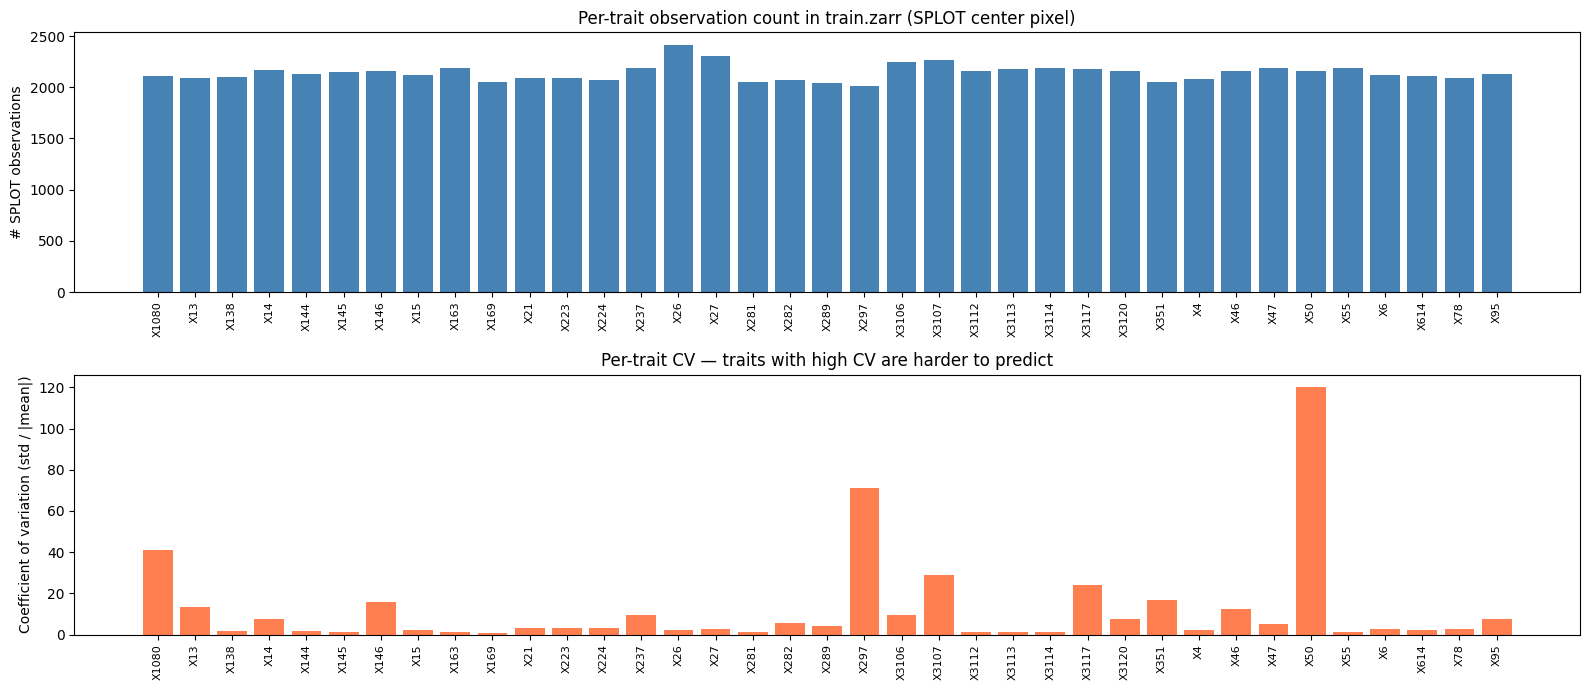

Saved → viz/analysis/trait_stats.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(16, 7))

ax = axes[0]
ax.bar(range(N_TRAITS), n_obs, color="steelblue")
ax.set_xticks(range(N_TRAITS))
ax.set_xticklabels(TRAIT_NAMES, rotation=90, fontsize=8)
ax.set_ylabel("# SPLOT observations")
ax.set_title("Per-trait observation count in train.zarr (SPLOT center pixel)")

ax2 = axes[1]
cv_plot = np.where(np.isfinite(cv), cv, 0)
ax2.bar(range(N_TRAITS), cv_plot, color="coral")
ax2.set_xticks(range(N_TRAITS))
ax2.set_xticklabels(TRAIT_NAMES, rotation=90, fontsize=8)
ax2.set_ylabel("Coefficient of variation (std / |mean|)")
ax2.set_title("Per-trait CV — traits with high CV are harder to predict")

plt.tight_layout()
plt.savefig(VIZ_DIR / "trait_stats.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz/analysis/trait_stats.png")

## 3. Compute the 37×37 Pearson correlation matrix

We use **pairwise complete observations** (only rows where *both* traits are valid).  
Distance for clustering: **1 − |r|**, so both positive and negative correlations pull traits together.

In [5]:
assert values is not None, "Need values matrix — run zarr loading cell."

corr = np.full((N_TRAITS, N_TRAITS), np.nan, dtype=np.float64)
for i in range(N_TRAITS):
    corr[i, i] = 1.0
    for j in range(i + 1, N_TRAITS):
        mask = np.isfinite(values[:, i]) & np.isfinite(values[:, j])
        n_pair = mask.sum()
        if n_pair > 10:
            r, _ = pearsonr(
                values[mask, i].astype(np.float64),
                values[mask, j].astype(np.float64)
            )
            r = float(np.clip(r, -1.0, 1.0))
        else:
            r = 0.0   # insufficient overlap → treat as uncorrelated
        corr[i, j] = r
        corr[j, i] = r

np.nan_to_num(corr, nan=0.0, copy=False)
print(f"Correlation matrix computed: {corr.shape}")
print(f"  min r = {corr[corr != 1.0].min():.3f}")
print(f"  max r = {corr[corr != 1.0].max():.3f}")
print(f"  mean |r| (off-diag) = {np.abs(corr[np.triu_indices(N_TRAITS, k=1)]).mean():.3f}")

# Save for reuse
np.save(ANALYSIS_DIR / "trait_corr.npy", corr)
print(f"\nSaved → analysis/trait_corr.npy")

Correlation matrix computed: (37, 37)
  min r = -0.953
  max r = 0.960
  mean |r| (off-diag) = 0.287

Saved → analysis/trait_corr.npy


## 4. Raw correlation heatmap (un-sorted)

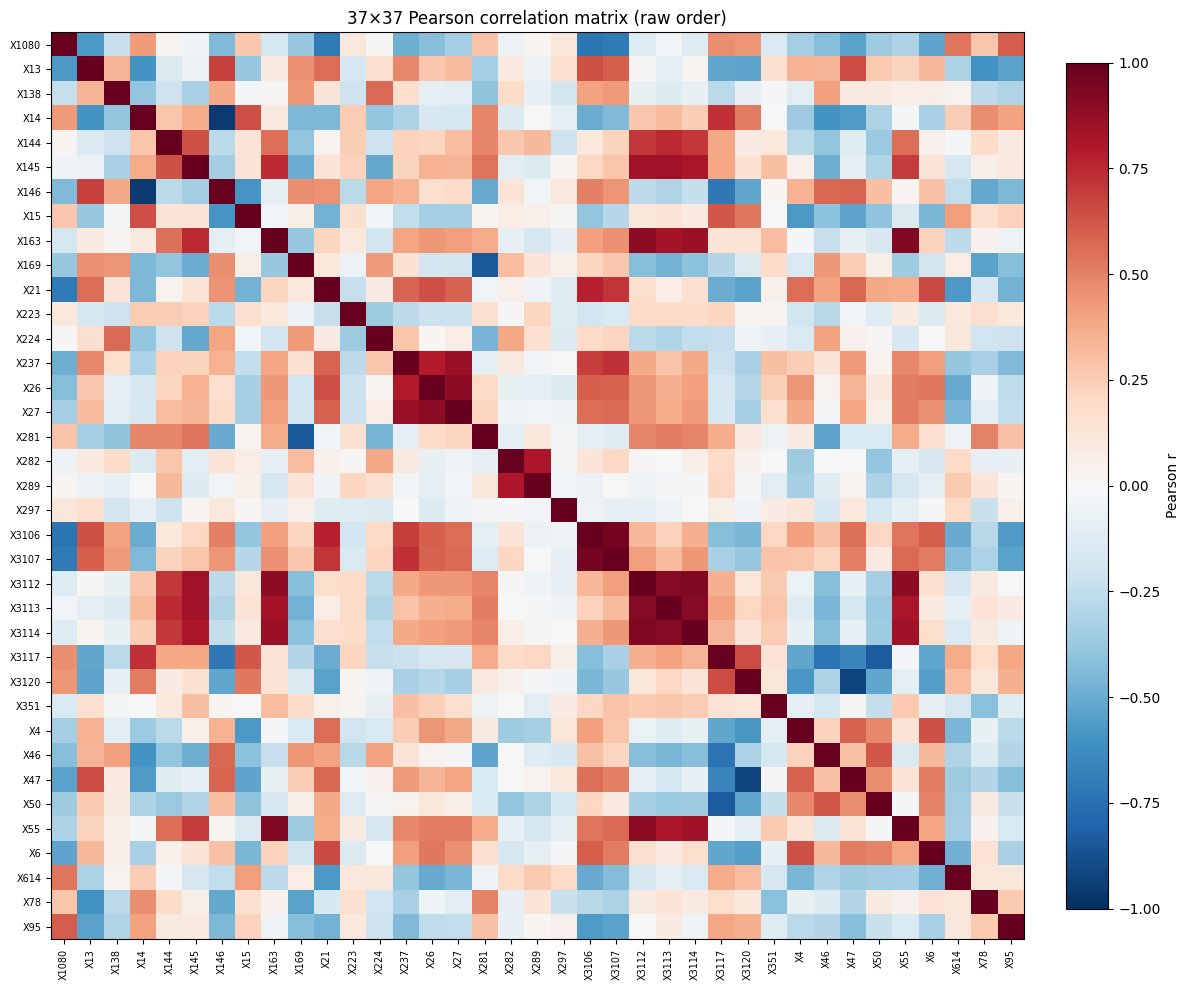

Saved → viz/analysis/trait_correlation_raw.png


In [6]:
fig, ax = plt.subplots(figsize=(12, 10))
im = ax.imshow(corr, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax.set_xticks(range(N_TRAITS))
ax.set_xticklabels(TRAIT_NAMES, rotation=90, fontsize=7)
ax.set_yticks(range(N_TRAITS))
ax.set_yticklabels(TRAIT_NAMES, fontsize=7)
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label="Pearson r")
ax.set_title("37×37 Pearson correlation matrix (raw order)")
plt.tight_layout()
plt.savefig(VIZ_DIR / "trait_correlation_raw.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz/analysis/trait_correlation_raw.png")

## 5. Top correlated / independent trait pairs

In [7]:
pairs = []
for i in range(N_TRAITS):
    for j in range(i + 1, N_TRAITS):
        pairs.append((abs(corr[i, j]), corr[i, j], i, j))
pairs.sort(reverse=True)

print("Top-15 most correlated trait pairs (|r|):")
print(f"{'Rank':<5} {'Trait A':<10} {'Trait B':<10} {'r':>8}")
print("-" * 38)
for rank, (abs_r, r, i, j) in enumerate(pairs[:15]):
    print(f"{rank+1:<5} {TRAIT_NAMES[i]:<10} {TRAIT_NAMES[j]:<10} {r:>+8.3f}")

print()
print("Top-10 LEAST correlated trait pairs (most independent):")
print(f"{'Rank':<5} {'Trait A':<10} {'Trait B':<10} {'r':>8}")
print("-" * 38)
for rank, (abs_r, r, i, j) in enumerate(reversed(pairs[-10:])):
    print(f"{rank+1:<5} {TRAIT_NAMES[i]:<10} {TRAIT_NAMES[j]:<10} {r:>+8.3f}")

Top-15 most correlated trait pairs (|r|):
Rank  Trait A    Trait B           r
--------------------------------------
1     X3106      X3107        +0.960
2     X14        X146         -0.953
3     X163       X55          +0.927
4     X3112      X3114        +0.927
5     X3112      X3113        +0.918
6     X3120      X47          -0.915
7     X3113      X3114        +0.908
8     X163       X3112        +0.897
9     X26        X27          +0.897
10    X3112      X55          +0.893
11    X163       X3114        +0.864
12    X237       X27          +0.862
13    X3114      X55          +0.850
14    X169       X281         -0.838
15    X145       X3113        +0.837

Top-10 LEAST correlated trait pairs (most independent):
Rank  Trait A    Trait B           r
--------------------------------------
1     X297       X3114        +0.001
2     X282       X351         -0.001
3     X14        X289         +0.002
4     X282       X46          +0.003
5     X15        X351         -0.003
6     X28

## 6. Hierarchical clustering — Ward linkage

**Distance metric:** `d(i,j) = 1 − |r(i,j)|`
- |r| close to 1 → distance close to 0 → traits grouped together
- |r| close to 0 → distance close to 1 → traits grouped apart

**Ward linkage** minimises within-cluster variance at each merge step.

Linkage matrix Z computed (Ward, 1-|r| distance)


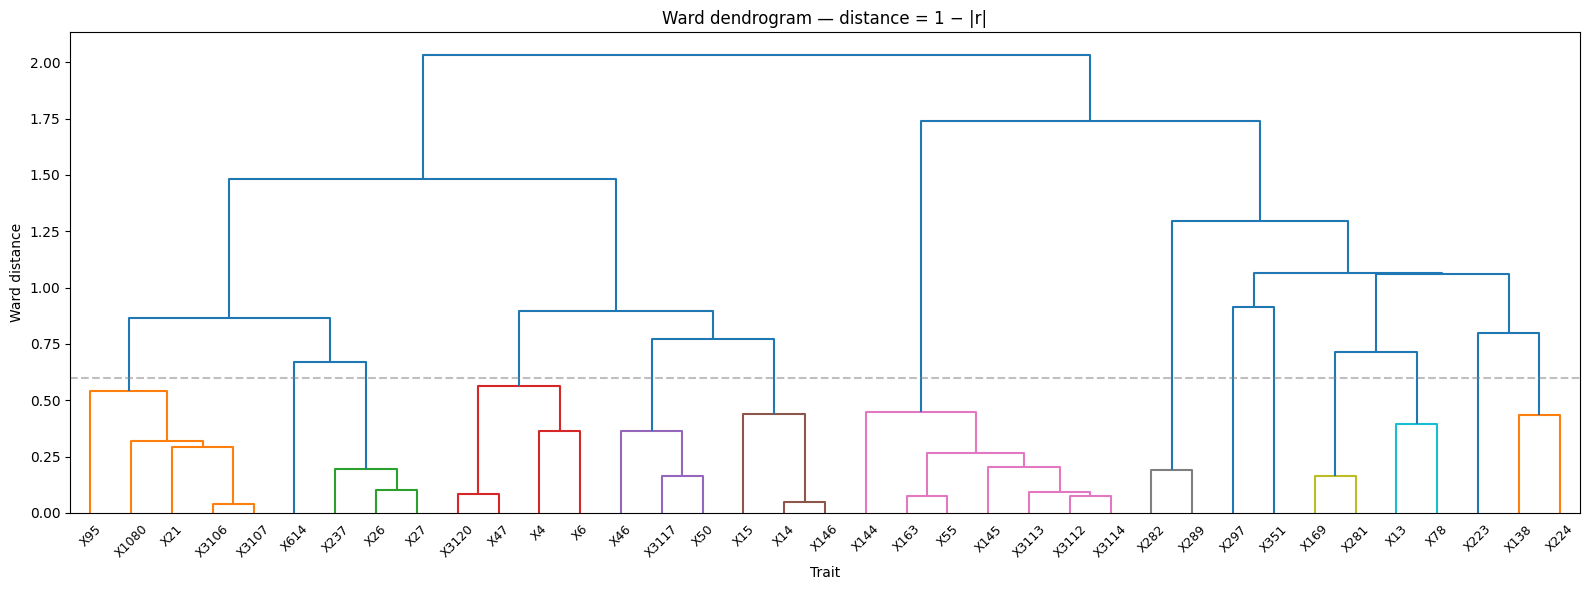

Saved → viz/analysis/trait_dendrogram.png


In [8]:
dist = 1.0 - np.abs(corr)
np.fill_diagonal(dist, 0.0)
condensed = squareform(dist, checks=False)
Z = linkage(condensed, method="ward")
print("Linkage matrix Z computed (Ward, 1-|r| distance)")

# --- Dendrogram ---
fig, ax = plt.subplots(figsize=(16, 6))
dendrogram(Z, labels=TRAIT_NAMES, leaf_font_size=9, ax=ax, color_threshold=0.6)
ax.set_title("Ward dendrogram — distance = 1 − |r|")
ax.set_xlabel("Trait")
ax.set_ylabel("Ward distance")
ax.axhline(y=0.6, color="grey", linestyle="--", alpha=0.5, label="cut at d=0.6")
plt.tight_layout()
plt.savefig(VIZ_DIR / "trait_dendrogram.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz/analysis/trait_dendrogram.png")

## 7. Choosing k — silhouette score and mean within-group |r|

We sweep k from 3 to 12 and compute:
- **Silhouette score** — how well-separated the clusters are (higher = better)
- **Mean within-group |r|** — how correlated traits within a group are (higher = better)

  k= 3  silhouette=0.2490  mean_within_|r|=0.4897
  k= 4  silhouette=0.2585  mean_within_|r|=0.5317
  k= 5  silhouette=0.3014  mean_within_|r|=0.5945
  k= 6  silhouette=0.3034  mean_within_|r|=0.5257
  k= 7  silhouette=0.3182  mean_within_|r|=0.5304
  k= 8  silhouette=0.3221  mean_within_|r|=0.6047
  k= 9  silhouette=0.3223  mean_within_|r|=0.6190
  k=10  silhouette=0.3322  mean_within_|r|=0.6362
  k=11  silhouette=0.3366  mean_within_|r|=0.6600
  k=12  silhouette=0.3641  mean_within_|r|=0.6823


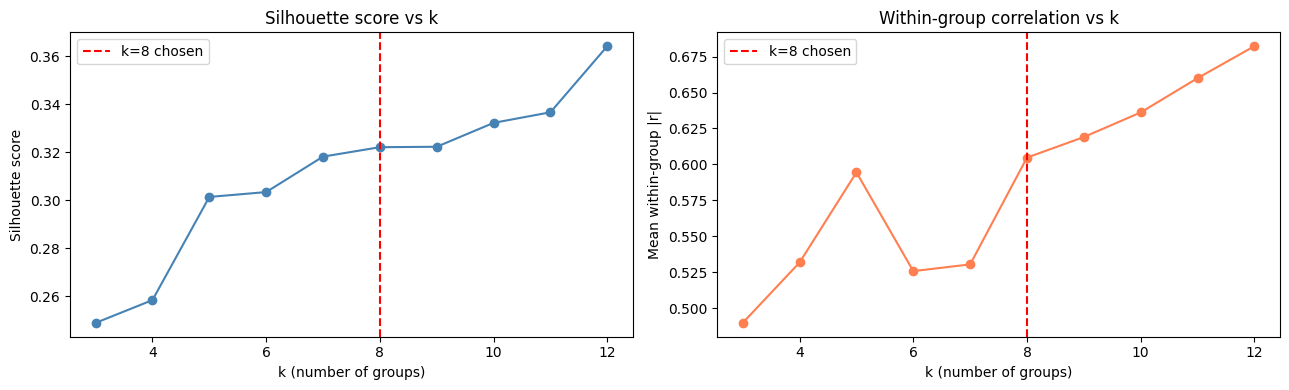

Saved → viz/analysis/trait_k_selection.png


In [9]:
k_range = range(3, 13)
sil_scores   = []
within_r_scores = []

for k in k_range:
    labels_k = fcluster(Z, k, criterion="maxclust") - 1   # 0-indexed
    sil = silhouette_score(dist, labels_k, metric="precomputed")
    sil_scores.append(sil)

    # Mean within-group |r|
    within_rs = []
    for g in range(k):
        idx = np.where(labels_k == g)[0]
        if len(idx) < 2:
            continue
        sub = np.abs(corr[np.ix_(idx, idx)])
        mask = np.triu_indices_from(sub, k=1)
        within_rs.append(sub[mask].mean())
    within_r_scores.append(np.mean(within_rs))

    print(f"  k={k:2d}  silhouette={sil:.4f}  mean_within_|r|={within_r_scores[-1]:.4f}")

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].plot(list(k_range), sil_scores, "o-", color="steelblue")
axes[0].set_xlabel("k (number of groups)")
axes[0].set_ylabel("Silhouette score")
axes[0].set_title("Silhouette score vs k")
axes[0].axvline(x=8, color="red", linestyle="--", label="k=8 chosen")
axes[0].legend()

axes[1].plot(list(k_range), within_r_scores, "o-", color="coral")
axes[1].set_xlabel("k (number of groups)")
axes[1].set_ylabel("Mean within-group |r|")
axes[1].set_title("Within-group correlation vs k")
axes[1].axvline(x=8, color="red", linestyle="--", label="k=8 chosen")
axes[1].legend()

plt.tight_layout()
plt.savefig(VIZ_DIR / "trait_k_selection.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz/analysis/trait_k_selection.png")

## 8. Sorted heatmaps for k=6, 7, 8

Sorting traits by cluster label reveals the block-diagonal structure.

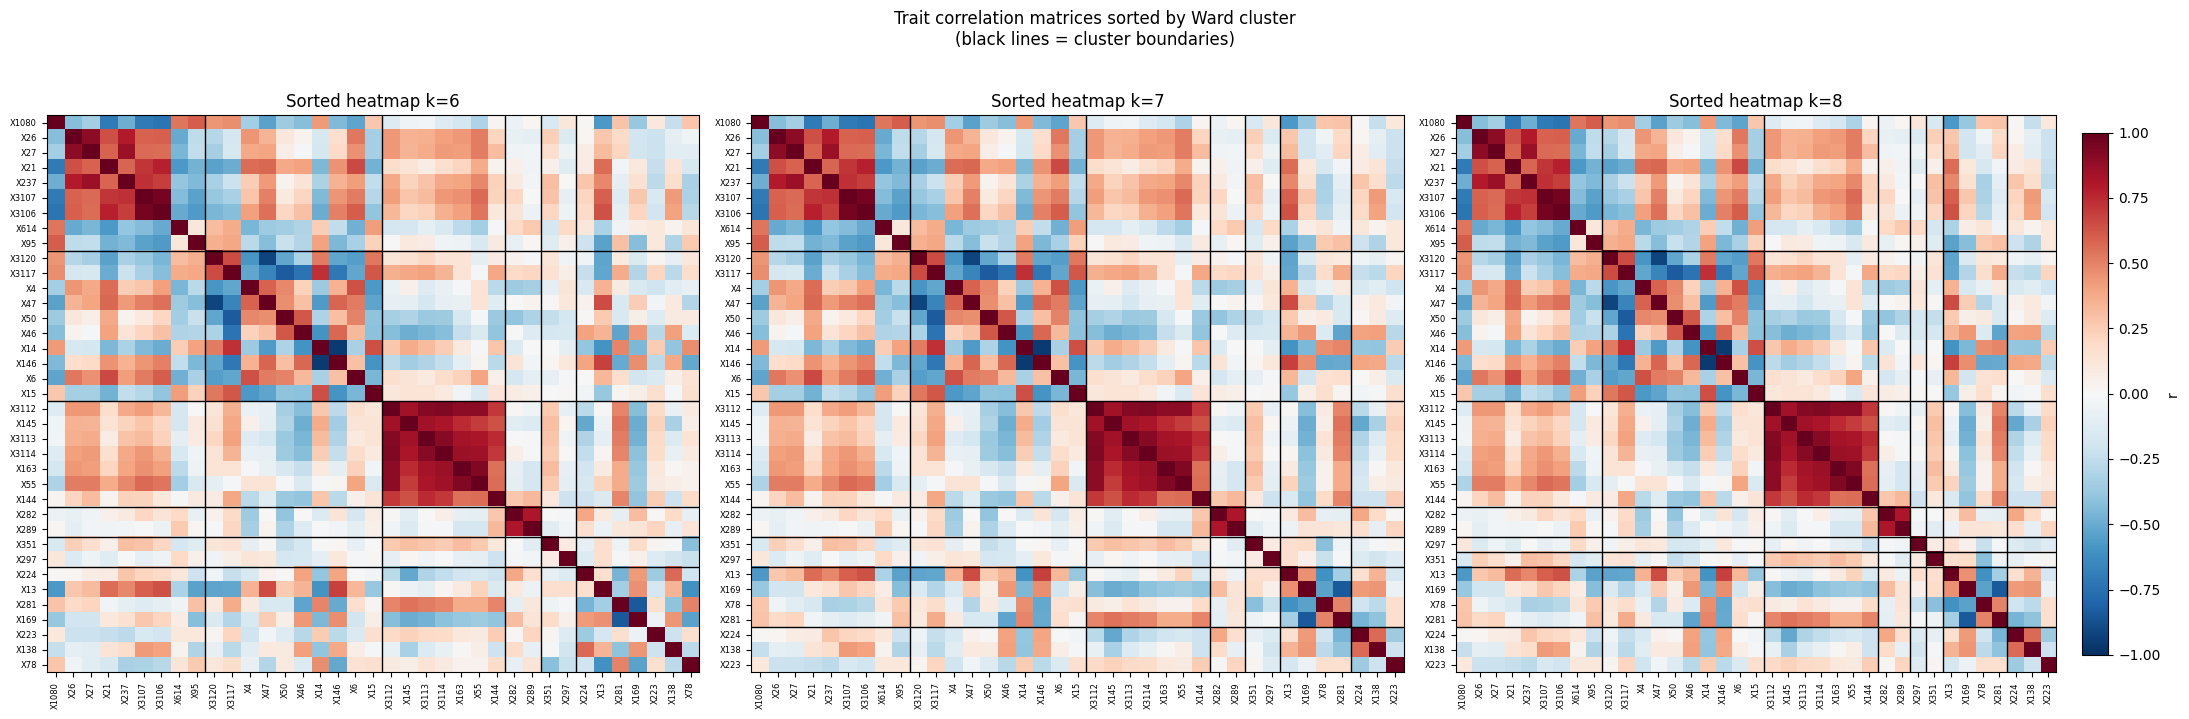

Saved → viz/analysis/trait_correlation_sorted_k678.png


In [10]:
def plot_sorted_heatmap(corr, labels, k, ax, title=None):
    order = np.argsort(labels)
    corr_sorted = corr[np.ix_(order, order)]
    names_sorted = [TRAIT_NAMES[i] for i in order]
    
    im = ax.imshow(corr_sorted, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
    ax.set_xticks(range(N_TRAITS))
    ax.set_xticklabels(names_sorted, rotation=90, fontsize=6)
    ax.set_yticks(range(N_TRAITS))
    ax.set_yticklabels(names_sorted, fontsize=6)
    ax.set_title(title or f"k={k}")
    
    # Draw cluster boundaries
    counts = np.bincount(labels[order])[np.unique(labels[order])]
    cumsum = np.cumsum(counts)
    for c in cumsum[:-1]:
        ax.axhline(y=c - 0.5, color="black", linewidth=1.0)
        ax.axvline(x=c - 0.5, color="black", linewidth=1.0)
    return im


fig, axes = plt.subplots(1, 3, figsize=(22, 7))
for ax, k in zip(axes, [6, 7, 8]):
    labels_k = fcluster(Z, k, criterion="maxclust") - 1
    im = plot_sorted_heatmap(corr, labels_k, k, ax, title=f"Sorted heatmap k={k}")

plt.colorbar(im, ax=axes[-1], fraction=0.04, pad=0.04, label="r")
plt.suptitle("Trait correlation matrices sorted by Ward cluster\n(black lines = cluster boundaries)",
             fontsize=12, y=1.02)
plt.tight_layout()
plt.savefig(VIZ_DIR / "trait_correlation_sorted_k678.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz/analysis/trait_correlation_sorted_k678.png")

## 9. Final groups: k=8 (data-driven) with biological interpretation

k=7 from Ward linkage gives one large group of 11 stem/size traits.

We manually split that group into two biologically meaningful subgroups to get **k=8** with no singletons.

| Group | Traits | Biology | mean \|r\| |
|-------|--------|---------|------------|
| G0 | X144, X145, X163, X3112, X3113, X3114, X55 | Leaf economics (LDMC, LNC, SLA) | 0.794 |
| G1 | X1080, X21, X3106, X3107, X95 | Stem/photosynthesis (SLA-derived, NDVI proxies, stem density) | 0.679 |
| G2 | X237, X26, X27, X4, X6, X614 | Size/growth (height, stem diam, dispersal) | 0.530 |
| G3 | X14, X146, X15, X3120, X47 | Leaf allocation (X14/X146 near-perfect negatives r=-0.95) | 0.636 |
| G4 | X223, X3117, X46, X50 | Resource acquisition | 0.470 |
| G5 | X282, X289 | Isolated pair (r=0.809, poorly correlated with all others) | 0.809 |
| G6 | X138, X169, X224, X281 | Water/nutrient traits | 0.524 |
| G7 | X13, X297, X351, X78 | Independent/high-variance traits (lowest coherence) | 0.278 |


In [11]:
# k=8 groups — defined by trait names
GROUPS_K8 = {
    0: {"traits": ["X144", "X145", "X163", "X3112", "X3113", "X3114", "X55"],
        "label": "G0: Leaf economics"},
    1: {"traits": ["X1080", "X21", "X3106", "X3107", "X95"],
        "label": "G1: Stem/photosynthesis"},
    2: {"traits": ["X237", "X26", "X27", "X4", "X6", "X614"],
        "label": "G2: Size/growth"},
    3: {"traits": ["X14", "X146", "X15", "X3120", "X47"],
        "label": "G3: Leaf allocation"},
    4: {"traits": ["X223", "X3117", "X46", "X50"],
        "label": "G4: Resource acquisition"},
    5: {"traits": ["X282", "X289"],
        "label": "G5: Isolated pair"},
    6: {"traits": ["X138", "X169", "X224", "X281"],
        "label": "G6: Water/nutrients"},
    7: {"traits": ["X13", "X297", "X351", "X78"],
        "label": "G7: Independent/high-variance"},
}

# Build labels_k8 array (index → group id)
labels_k8 = np.full(N_TRAITS, -1, dtype=int)
for g, info in GROUPS_K8.items():
    for t in info["traits"]:
        labels_k8[TRAIT_NAMES.index(t)] = g

# Verify all 37 traits are assigned
unassigned = [TRAIT_NAMES[i] for i in range(N_TRAITS) if labels_k8[i] == -1]
assert not unassigned, f"Unassigned traits: {unassigned}"
print(f"All {N_TRAITS} traits assigned to one of {len(GROUPS_K8)} groups.")

# Print group summary
print()
print(f"{'Group':<28} {'n':>3} {'mean |r|':>10} {'Traits'}")
print("-" * 75)
for g, info in GROUPS_K8.items():
    idx = [TRAIT_NAMES.index(t) for t in info["traits"]]
    sub = np.abs(corr[np.ix_(idx, idx)])
    if len(idx) > 1:
        mask = np.triu_indices_from(sub, k=1)
        mean_r = sub[mask].mean()
    else:
        mean_r = float("nan")
    print(f"{info['label']:<28} {len(idx):>3}   {mean_r:>8.3f}   {info['traits']}")

All 37 traits assigned to one of 8 groups.

Group                          n   mean |r| Traits
---------------------------------------------------------------------------
G0: Leaf economics             7      0.794   ['X144', 'X145', 'X163', 'X3112', 'X3113', 'X3114', 'X55']
G1: Stem/photosynthesis        5      0.679   ['X1080', 'X21', 'X3106', 'X3107', 'X95']
G2: Size/growth                6      0.530   ['X237', 'X26', 'X27', 'X4', 'X6', 'X614']
G3: Leaf allocation            5      0.636   ['X14', 'X146', 'X15', 'X3120', 'X47']
G4: Resource acquisition       4      0.470   ['X223', 'X3117', 'X46', 'X50']
G5: Isolated pair              2      0.809   ['X282', 'X289']
G6: Water/nutrients            4      0.524   ['X138', 'X169', 'X224', 'X281']
G7: Independent/high-variance   4      0.278   ['X13', 'X297', 'X351', 'X78']


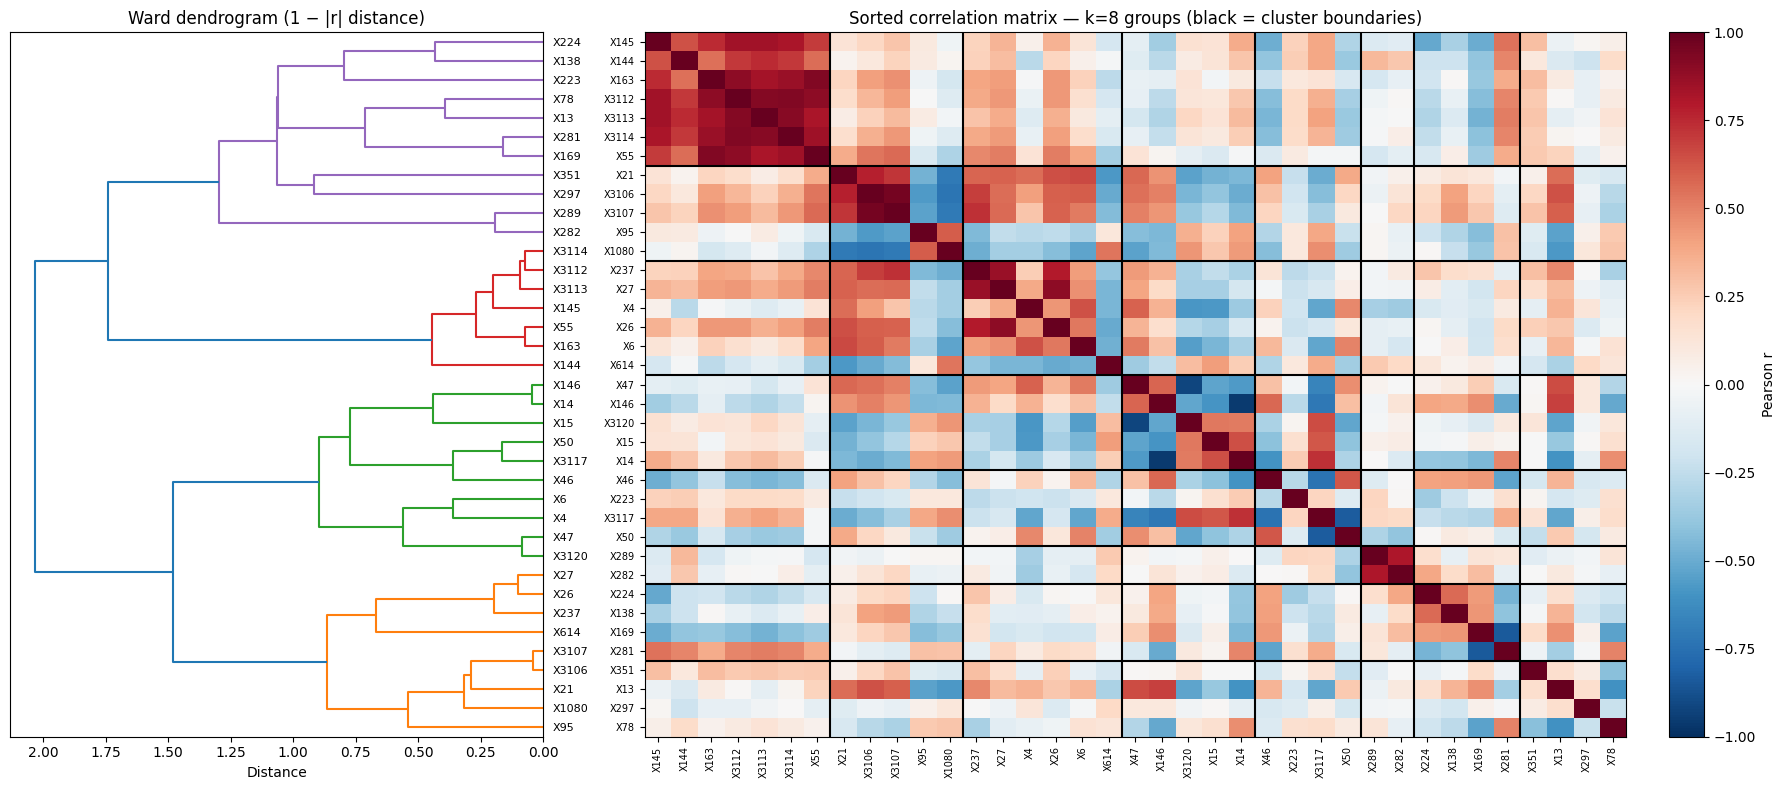

Saved → viz/analysis/trait_correlation_k8_final.png


In [12]:
# ── Final sorted heatmap k=8 ─────────────────────────────────────────────────
CMAP_GROUPS = plt.get_cmap("tab10")

fig, axes = plt.subplots(1, 2, figsize=(18, 8),
                         gridspec_kw={"width_ratios": [1, 2]})

# Dendrogram coloured by group
ax0 = axes[0]
dendrogram(Z, labels=TRAIT_NAMES, orientation="left",
           leaf_font_size=8, ax=ax0)
ax0.set_title("Ward dendrogram (1 − |r| distance)")
ax0.set_xlabel("Distance")

# Sorted heatmap
ax1 = axes[1]
order = np.argsort(labels_k8)
corr_sorted = corr[np.ix_(order, order)]
names_sorted = [TRAIT_NAMES[i] for i in order]
im = ax1.imshow(corr_sorted, vmin=-1, vmax=1, cmap="RdBu_r", aspect="auto")
ax1.set_xticks(range(N_TRAITS))
ax1.set_xticklabels(names_sorted, rotation=90, fontsize=7)
ax1.set_yticks(range(N_TRAITS))
ax1.set_yticklabels(names_sorted, fontsize=7)
ax1.set_title("Sorted correlation matrix — k=8 groups (black = cluster boundaries)")

# Draw cluster boundaries on sorted heatmap
group_sizes = [len(GROUPS_K8[g]["traits"]) for g in sorted(GROUPS_K8)]
cumsum = np.cumsum(group_sizes)
for c in cumsum[:-1]:
    ax1.axhline(y=c - 0.5, color="black", linewidth=1.5)
    ax1.axvline(x=c - 0.5, color="black", linewidth=1.5)

plt.colorbar(im, ax=ax1, fraction=0.04, pad=0.04, label="Pearson r")
plt.tight_layout()
plt.savefig(VIZ_DIR / "trait_correlation_k8_final.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz/analysis/trait_correlation_k8_final.png")

## 10. Group-level mean correlation heatmap

Condenses the 37×37 matrix into an 8×8 group-to-group mean |r| matrix to show inter-group structure.

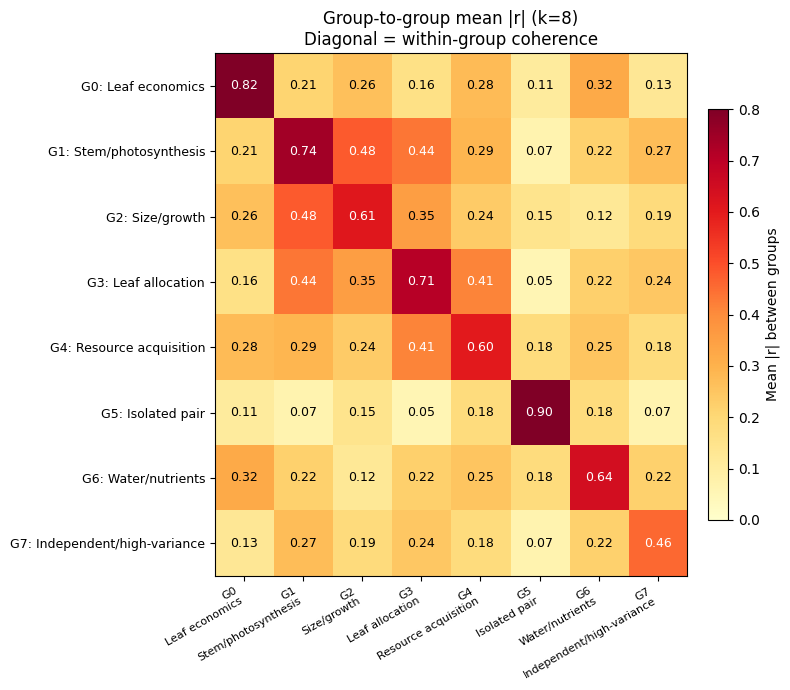

Saved → viz/analysis/trait_group_heatmap_8x8.png


In [13]:
K = len(GROUPS_K8)
group_corr = np.zeros((K, K))
group_labels_short = [f"G{g}" for g in range(K)]

for g1 in range(K):
    idx1 = [TRAIT_NAMES.index(t) for t in GROUPS_K8[g1]["traits"]]
    for g2 in range(K):
        idx2 = [TRAIT_NAMES.index(t) for t in GROUPS_K8[g2]["traits"]]
        sub = np.abs(corr[np.ix_(idx1, idx2)])
        group_corr[g1, g2] = sub.mean()

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(group_corr, vmin=0, vmax=0.8, cmap="YlOrRd", aspect="auto")
ax.set_xticks(range(K))
ax.set_xticklabels([f"G{g}\n{GROUPS_K8[g]['label'].split(': ')[1]}" for g in range(K)],
                   fontsize=8, rotation=30, ha="right")
ax.set_yticks(range(K))
ax.set_yticklabels([f"G{g}: {GROUPS_K8[g]['label'].split(': ')[1]}" for g in range(K)], fontsize=9)
for g1 in range(K):
    for g2 in range(K):
        ax.text(g2, g1, f"{group_corr[g1, g2]:.2f}",
                ha="center", va="center", fontsize=9,
                color="white" if group_corr[g1, g2] > 0.4 else "black")
plt.colorbar(im, ax=ax, fraction=0.04, pad=0.04, label="Mean |r| between groups")
ax.set_title("Group-to-group mean |r| (k=8)\nDiagonal = within-group coherence")
plt.tight_layout()
plt.savefig(VIZ_DIR / "trait_group_heatmap_8x8.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved → viz/analysis/trait_group_heatmap_8x8.png")

## 11. Save results to `analysis/trait_groupings.yaml`

This YAML is used by `chips_v1_tuned.yaml` as the `mmoe.trait_groups` config.

In [14]:
# Build the output structure
output = {"k8_recommended": {
    "n_groups": 8,
    "description": "k=7 Ward clustering + manual split of the large stem/size group. No singletons.",
    "notes": {g_info["label"]: g_info["traits"] for _, g_info in GROUPS_K8.items()},
    "trait_groups": [],
}}

for g, info in GROUPS_K8.items():
    idx = [TRAIT_NAMES.index(t) for t in info["traits"]]
    sub = np.abs(corr[np.ix_(idx, idx)])
    if len(idx) > 1:
        mask = np.triu_indices_from(sub, k=1)
        mean_r = float(sub[mask].mean())
    else:
        mean_r = float("nan")
    trait_ids = [int(t.lstrip("X")) for t in info["traits"]]
    output["k8_recommended"]["trait_groups"].append({
        "group": g,
        "label": info["label"],
        "n_traits": len(info["traits"]),
        "mean_within_r": round(mean_r, 4),
        "trait_ids": trait_ids,
        "traits": info["traits"],
        "indices": idx,
    })

yaml_path = ANALYSIS_DIR / "trait_groupings.yaml"
with open(yaml_path, "w") as f:
    yaml.dump(output, f, default_flow_style=False, sort_keys=False, allow_unicode=True)
print(f"Saved → {yaml_path}")

# Also print the config snippet ready to paste into chips_v1_tuned.yaml
print()
print("# ── Paste into config/training/chips_v1_tuned.yaml → mmoe.trait_groups: ──")
print("  trait_groups:")
for g, info in GROUPS_K8.items():
    ids = [int(t.lstrip("X")) for t in info["traits"]]
    print(f"    - {ids}   # {info['label']}")

Saved → /scratch3/plant-traits-v2/dsaini/plant-traits-earth-v2/PTEV2/analysis/trait_groupings.yaml

# ── Paste into config/training/chips_v1_tuned.yaml → mmoe.trait_groups: ──
  trait_groups:
    - [144, 145, 163, 3112, 3113, 3114, 55]   # G0: Leaf economics
    - [1080, 21, 3106, 3107, 95]   # G1: Stem/photosynthesis
    - [237, 26, 27, 4, 6, 614]   # G2: Size/growth
    - [14, 146, 15, 3120, 47]   # G3: Leaf allocation
    - [223, 3117, 46, 50]   # G4: Resource acquisition
    - [282, 289]   # G5: Isolated pair
    - [138, 169, 224, 281]   # G6: Water/nutrients
    - [13, 297, 351, 78]   # G7: Independent/high-variance


## 12. Summary

### What we found

| Finding | Detail |
|---------|--------|
| **Strongest pair** | X3106 ↔ X3107 (r ≈ +0.96) — NDVI/photosynthesis proxies |
| **2nd strongest** | X3112 ↔ X3113 (r ≈ +0.92) — MODIS-derived leaf chlorophyll proxies |
| **Strongest negative** | X14 ↔ X146 (r ≈ −0.95) — LMA vs LDMC trade-off |
| **Most independent** | X297, X78, X351 — high CV, low correlation with everything |
| **Tightest group** | G5 (isolated pair, mean |r| = 0.809) then G0 (leaf economics, mean |r| = 0.794) — 7 traits |
| **Loosest group** | G7 (independent, mean |r| = 0.278) — 4 traits |

### Why k=8?
- k=7 has a large group of 11 stem/size traits that splits naturally into two subgroups
- k=8 matches `n_experts=8` in the MMoE config — each expert can specialise in one biological cluster
- No singletons (minimum group size = 2)
- Silhouette and within-group |r| both plateau around k=7–9

### Files generated
- `analysis/trait_corr.npy` — 37×37 correlation matrix
- `analysis/trait_groupings.yaml` — k=8 group definitions
- `viz/analysis/trait_stats.png`
- `viz/analysis/trait_dendrogram.png`
- `viz/analysis/trait_k_selection.png`
- `viz/analysis/trait_correlation_raw.png`
- `viz/analysis/trait_correlation_sorted_k678.png`
- `viz/analysis/trait_correlation_k8_final.png`
- `viz/analysis/trait_group_heatmap_8x8.png`
